In [1]:
# General Overview of the Plan
"""
This is the Dynamic Airline Factor Laboratory, where instead of parts we will be manufacturing Sharpe
Downloads, cleans, and prepares market data for the rolling PCA statistical arbitrage pipeline.
Within this magnificent universe, we shall evaluate DAL, UAL, AAL, LUV, ALK, JBLU, CPA against the benchmark S&P 500
Asides from the SPY and JETS, we will include BZ=F (Brent Crude) and the ^VIX (CBOE Volatility Index) as the risk-regime litmus test
Training: 2015-01-01 --> 2019-12-31
Validation: 2022-01-01 --> 2026-07-17
"""

'\nThis is the Dynamic Airline Factor Laboratory, where instead of parts we will be manufacturing Sharpe\nDownloads, cleans, and prepares market data for the rolling PCA statistical arbitrage pipeline.\nWithin this magnificent universe, we shall evaluate DAL, UAL, AAL, LUV, ALK, JBLU, CPA against the benchmark S&P 500\nAsides from the SPY and JETS, we will include BZ=F (Brent Crude) and the ^VIX (CBOE Volatility Index) as the risk-regime litmus test\nTraining: 2015-01-01 --> 2019-12-31\nValidation: 2022-01-01 --> 2026-07-17\n'

In [2]:
# Welcome to Japeshwar Singh's project, but please call me Jay :)
# This moves up a folder to access the juicy .py data
import sys
import os
print("Path:", os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('..'))

Path: C:\Users\japes\airline_factor_lab


In [3]:
# The Classics
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt
import models as md
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok=True)
print("data.py found:", os.path.exists('../data.py'))

data.py found: True


In [4]:
# Starting Data
airline_returns, macro_returns, prices = dt.load_data()
print(f"Shape: {airline_returns.shape}")
airline_returns.head()

Airlines: 7 tickers
Macro: 4 tickers
Dates: 2903 trading days
Range: 2015-01-05 -> 2026-07-16
Training: 2015-01-05 -> 2019-12-31
Validation: 2022-01-01 -> 2026-07-16
Shape: (2903, 7)


Ticker,DAL,UAL,AAL,LUV,ALK,JBLU,CPA
Date,,,,,,,
2015-01-05,-0.016814,-0.002868,-0.000557,-0.024903,-0.014357,-0.036766,-0.013202
2015-01-06,-0.023856,-0.024020,-0.015713,-0.028747,-0.011841,-0.016562,-0.009495
2015-01-07,-0.005308,0.014603,-0.000566,0.008368,0.015198,0.008647,0.000298
2015-01-08,0.025642,0.016797,0.012187,0.026127,0.017114,-0.014677,0.013814
2015-01-09,-0.027560,-0.019701,-0.031039,-0.026372,-0.016109,-0.034180,0.004205


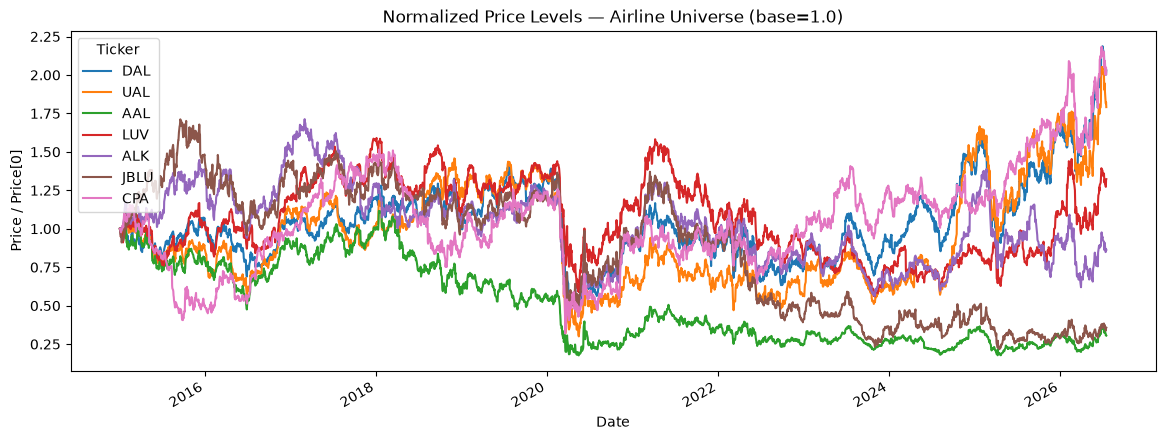

In [19]:
# Cell 4 — return distributions
(prices[dt.airlines].dropna() /
 prices[dt.airlines].dropna().iloc[0]).plot(figsize=(14,5),title="Normalized Price Levels — Airline Universe (base=1.0)")
plt.ylabel("Price / Price[0]")
plt.show()

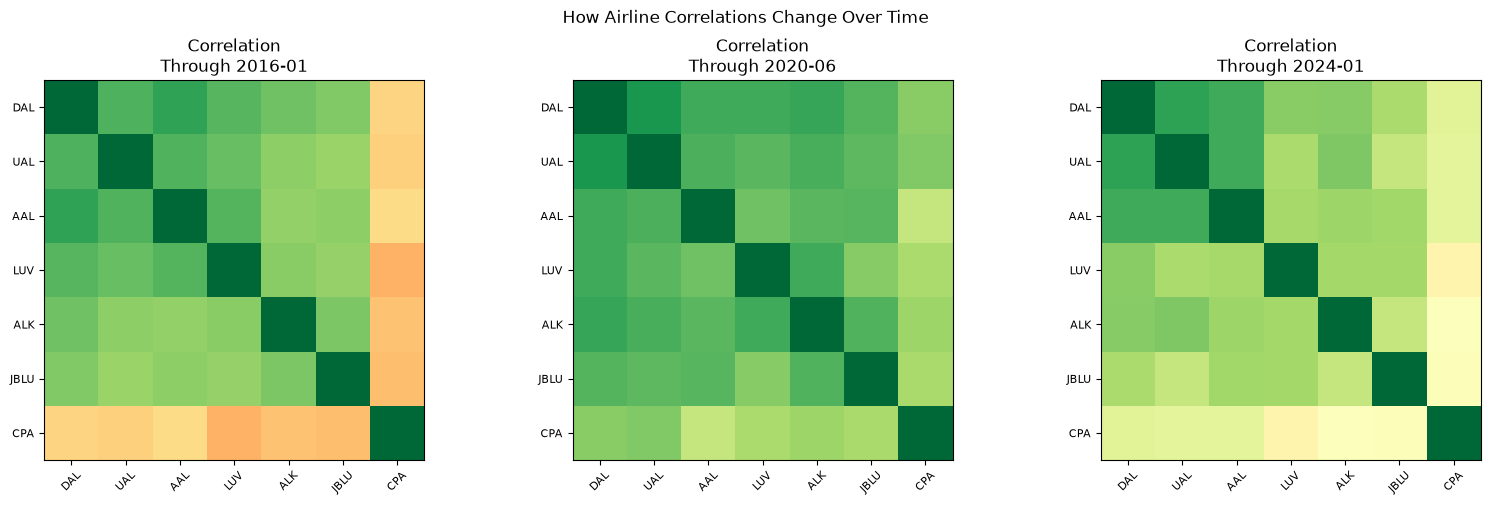

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
dates = ['2016-01-01', '2020-06-01', '2024-01-01']
for ax, d in zip(axes, dates):
    subset = airline_returns[airline_returns.index <= d].tail(252)
    corr   = subset.corr()
    im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, fontsize=8)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
    ax.set_title(f"Correlation\nThrough {d[:7]}")
plt.suptitle("How Airline Correlations Change Over Time")
plt.tight_layout()
plt.show()

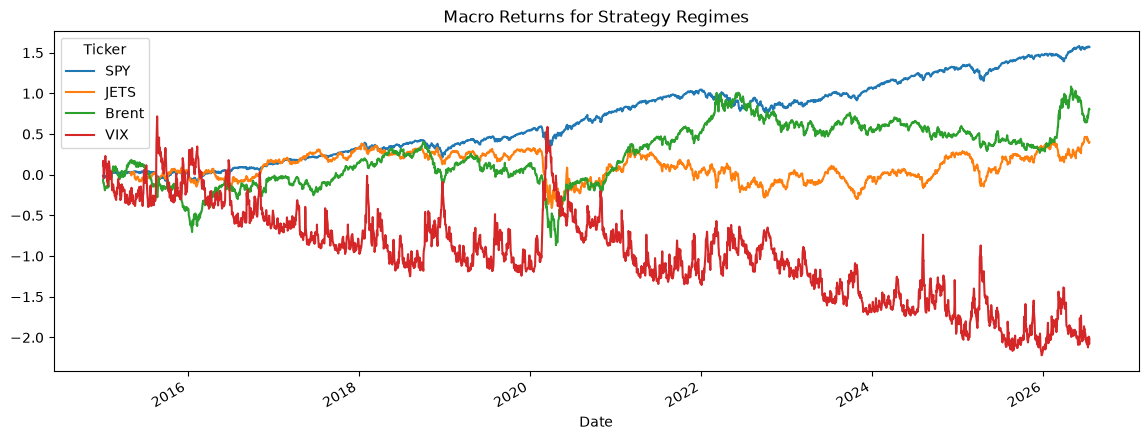

In [18]:
macro_returns[['SPY','JETS','Brent','VIX']].cumsum().plot(figsize=(14,5),title="Macro Returns for Strategy Regimes")
plt.show()

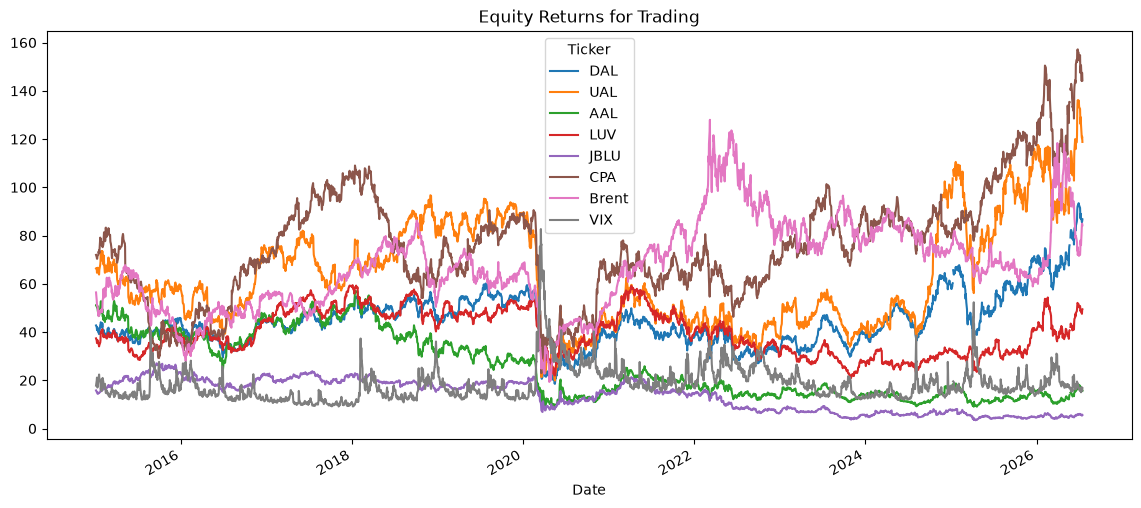

In [17]:
# Price Charts
prices[["DAL","UAL","AAL","LUV","JBLU","CPA","Brent","VIX"]].plot(figsize=(14,6),title="Equity Returns for Trading")
plt.show()

<Axes: xlabel='Date'>

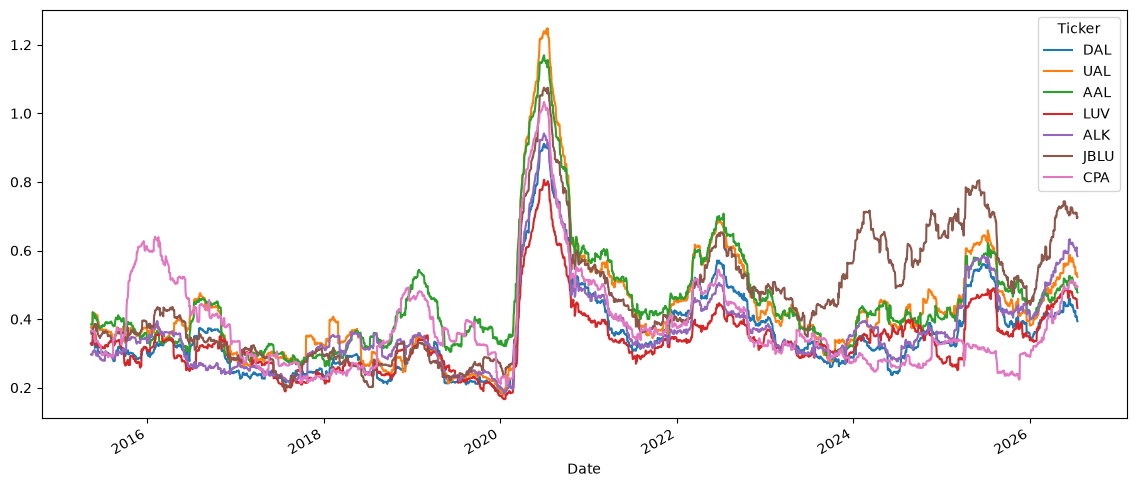

In [9]:
# Rolling Volatility
rolling_vol = airline_returns.rolling(90).std()*np.sqrt(252)
rolling_vol.plot(figsize=(14,6))

In [10]:
prices.to_csv(output_dir / "airline_returns.csv")

In [11]:
# Thanks for your time, allow me to take you to the next Exhibit (02_Models.ipynb)!